# Optimization landscape
This file is to plot the optimization landscape of two parameters in QAOA similar to the ascending CVaR paper: https://arxiv.org/pdf/2105.11766.


In [13]:
# Import pakcages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import math
from dataclasses import dataclass

from IPython.display import display
import pennylane as qml
from pennylane import numpy as qnp

import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)

## Set configurations

In [41]:
@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


MAIN_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=2.0", "qtl", gamma=2.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=20,
        schedule="linear",
        color="#9467bd",
    ),
]


SCHEDULE_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=20,
        schedule="linear",
        color="#9467bd",
    ),
    ObjectiveSpec(
        "QTL schedule sigmoid",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=20,
        schedule="sigmoid",
        color="#e377c2",
    ),
    ObjectiveSpec(
        "QTL reverse linear",
        "qtl_schedule",
        gamma_start=5,
        gamma_end=20,
        schedule="linear",
        color="#7f7f7f",
    ),
]

FIXED_GAMMA_GRID = [0.5, 5, 20, 100, 200]
GAMMA_GRID_OBJECTIVES = [
    ObjectiveSpec(f"QTL gamma={gamma}", "qtl", gamma=gamma, color=plt.cm.viridis(i / (len(FIXED_GAMMA_GRID) - 1)))
    for i, gamma in enumerate(FIXED_GAMMA_GRID)
] + [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="linear",
        color="#9467bd",
    ),
]

CURVE_OBJECTIVES = ["Expectation", "QTL gamma=2.0", "QTL gamma=5.0", "QTL schedule linear"]
HARD_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]
BUDGET_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]

ALL_OBJECTIVES = {
    obj.name: obj
    for obj in MAIN_OBJECTIVES + SCHEDULE_OBJECTIVES + GAMMA_GRID_OBJECTIVES
}
OBJECTIVE_COLORS = {name: obj.color for name, obj in ALL_OBJECTIVES.items()}

FAST_CONFIG = {
    # "graph_families": ["regular3"],
    "graph_families": ["erdos_renyi"],
    "sizes": [6],
    # "sizes": [8, 10, 12],
    # "depths": [1, 2, 3],
    "depths": [1],
    # "depths": [3],
    "seeds": [0],
    # "seeds": [0, 1, 2],
    "lr": 0.18,
    "lr_decay_power": 0.55,
    "lr_decay_offset": 6.0,
    "beta_mom": 0.7,
    "gamma_lr_penalty": 0.02,
    "grad_clip": 2.5,
    "steps": 150,
    "shots": 1024,
    "gradient_probes": 4,
    "target_ratio": 0.99,
    "curve_n": 8,
    "summary_n": 8,
    "summary_p": 2,
    "budget_n": 8,
    "budget_p": 2,
    "budget_seeds": [0, 1, 2],
    "budget_shots_grid": [64, 128, 256, 512],
    "budget_total_shots": 15360,
    "gamma_grid_n": 8,
    "gamma_grid_p": 2,
    "schedule_n": 8,
    "schedule_p": 2,
}

FULL_CONFIG = {
    **FAST_CONFIG,
    "graph_families": ["erdos_renyi"],
    # "graph_families": ["regular3", "erdos_renyi"],
    "seeds": list(range(8)),
    "steps": 150,
    "shots": 1024,
    "gradient_probes": 8,
    "budget_seeds": list(range(8)),
}

RUN_CONFIG = FAST_CONFIG
print("Running config:", RUN_CONFIG)

EXACT_SMALL_SCALE_CONFIG = {
    **FAST_CONFIG,
    "sizes": [8],
    "depths": [2],
    "seeds": [0],
    "steps": 150,
    "shots": 256,
}


Running config: {'graph_families': ['erdos_renyi'], 'sizes': [6], 'depths': [1], 'seeds': [0], 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5, 'steps': 150, 'shots': 1024, 'gradient_probes': 4, 'target_ratio': 0.99, 'curve_n': 8, 'summary_n': 8, 'summary_p': 2, 'budget_n': 8, 'budget_p': 2, 'budget_seeds': [0, 1, 2], 'budget_shots_grid': [64, 128, 256, 512], 'budget_total_shots': 15360, 'gamma_grid_n': 8, 'gamma_grid_p': 2, 'schedule_n': 8, 'schedule_p': 2}


## Max-Cut problem

In [3]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())

## QAOA circuit

In [4]:
def make_exact_qaoa_probs(n, edges):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, diff_method=None)
    def circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.probs(wires=range(n))

    return circuit


## Calculation of loss function and observables

In [ ]:
def qtl_loss_from_distribution(probs, losses, gamma):
    probs = qml.math.asarray(probs)
    losses = qml.math.asarray(losses)
    if gamma is None or abs(gamma) < 1e-12:
        return qml.math.dot(probs, losses)
    loss_min = qml.math.min(losses)
    shifted = losses - loss_min
    weighted = qml.math.sum(probs * qml.math.exp(-gamma * shifted))
    return loss_min - qml.math.log(weighted) / gamma


def _sigmoid_frac(frac):
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))


def scheduled_gamma(spec, step, total_steps):
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    elif spec.schedule == "piecewise":
        if frac < 0.5:
            schedule_frac = 0.2 * frac / 0.5
        else:
            schedule_frac = 0.2 + 0.8 * (frac - 0.5) / 0.5
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))


def objective_loss_from_distribution(probs, cuts, c_max: float, spec: ObjectiveSpec, step: int, total_steps: int):
    losses = c_max - qml.math.asarray(cuts)
    if spec.kind == "expectation":
        return qml.math.dot(probs, losses)
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma)


def make_exact_objective(n, edges, spec, total_steps):
    _, cuts, c_max = exact_cut_data(n, edges)
    probs_fn = make_exact_qaoa_probs(n, edges)

    def objective(params, step):
        probs = np.asarray(probs_fn(np.mod(np.asarray(params, dtype=float), 2 * np.pi)), dtype=float)
        loss, gamma = exact_loss_from_distribution(probs, cuts, c_max, spec, step, total_steps)
        return float(loss), {
            "mean_ratio": float(np.dot(probs, cuts) / c_max),
            "optimal_mass": float(probs[cuts == c_max].sum()),
            "gamma": gamma,
        }

    return objective, cuts, c_max

def exact_loss_from_distribution(probs, cuts, c_max, spec, step, total_steps):
    losses = c_max - cuts
    if spec.kind == "expectation":
        return float(np.dot(probs, losses)), np.nan
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma), gamma


## Calculation of landscape properties

In [6]:
def smooth_landscape(surface, rounds=2):
    smoothed = np.asarray(surface, dtype=float).copy()
    for _ in range(rounds):
        updated = smoothed.copy()
        for i in range(1, smoothed.shape[0] - 1):
            for j in range(1, smoothed.shape[1] - 1):
                updated[i, j] = np.mean(smoothed[i - 1:i + 2, j - 1:j + 2])
        smoothed = updated
    return smoothed

    
def find_grid_minima(surface, min_separation=5, prominence=0.02, smooth_rounds=2):
    smoothed = smooth_landscape(surface, rounds=smooth_rounds)
    span = float(np.max(smoothed) - np.min(smoothed))
    raw_candidates = []
    rows, cols = smoothed.shape

    for i in range(2, rows - 2):
        for j in range(2, cols - 2):
            patch = smoothed[i - 2:i + 3, j - 2:j + 3]
            value = smoothed[i, j]
            if value > float(np.min(patch)) + 1e-9:
                continue
            basin_depth = float(np.mean(patch) - value)
            if basin_depth < prominence * span:
                continue
            raw_candidates.append((j, i, value, basin_depth))

    raw_candidates.sort(key=lambda item: (item[2], -item[3]))
    selected = []
    for candidate in raw_candidates:
        j, i, value, basin_depth = candidate
        if all((j - pj) ** 2 + (i - pi) ** 2 >= min_separation ** 2 for pj, pi, _, _ in selected):
            selected.append(candidate)

    if not selected:
        return [], [], smoothed

    global_value = min(value for _, _, value, _ in selected)
    local_points = []
    global_points = []
    for j, i, value, _ in selected:
        if value <= global_value + 0.01 * span:
            global_points.append((j, i))
        else:
            local_points.append((j, i))
    return local_points, global_points, smoothed



def minimum_distance(point, points):
    if not points:
        return np.inf
    return min(np.hypot(point[0] - other[0], point[1] - other[1]) for other in points)



## Main executing functions

In [22]:
def build_landscape(objective, gamma_grid, beta_grid, step):
    values = np.zeros((len(beta_grid), len(gamma_grid)))
    for i, beta in enumerate(beta_grid):
        for j, gamma in enumerate(gamma_grid):
            val, _ = objective(np.array([gamma, beta]), step)
            values[i, j] = val
    return values

def finite_difference_grad(objective, params, step, eps=1e-3):
    grad = np.zeros_like(params, dtype=float)
    for i in range(len(params)):
        shift = np.zeros_like(params)
        shift[i] = eps
        plus, _ = objective(params + shift, step)
        minus, _ = objective(params - shift, step)
        grad[i] = (plus - minus) / (2.0 * eps)
    return grad
    
def exact_descent_trace(objective, init_params, steps, lr=0.18):
    params = np.asarray(init_params, dtype=float).copy()
    rows = []
    for step in range(steps):
        value, metrics = objective(params, step)
        rows.append(
            {
                "iteration": step + 1,
                "param_gamma": float(params[0]),
                "param_beta": float(params[1]),
                "objective": float(value),
                "mean_ratio": float(metrics["mean_ratio"]),
                "optimal_mass": float(metrics["optimal_mass"]),
                "gamma": metrics["gamma"],
            }
        )
        grad = finite_difference_grad(objective, params, step)
        params = np.mod(params - lr * grad, 2 * np.pi)
    return pd.DataFrame(rows)


def find_landscape_demo(n, family):
    fixed_spec = ALL_OBJECTIVES["QTL gamma=20.0"]
    sched_spec = ALL_OBJECTIVES["QTL schedule linear"]
    reverse_spec = ALL_OBJECTIVES["QTL reverse linear"]
    best = None
    best_gap = -np.inf

    for graph_seed in range(8):
        graph = make_graph(n, family, graph_seed)
        edges = sorted(graph.edges())
        fixed_obj, _, _ = make_exact_objective(n, edges, fixed_spec, total_steps=24)
        sched_obj, _, _ = make_exact_objective(n, edges, sched_spec, total_steps=24)
        reverse_obj, _, _ = make_exact_objective(n, edges, reverse_spec, total_steps=24)
        for init_seed in range(20):
            rng = np.random.default_rng(50_000 + 100 * graph_seed + init_seed)
            init_params = rng.uniform(0.0, np.pi, size=2)
            fixed_trace = exact_descent_trace(fixed_obj, init_params, steps=24, lr=0.16)
            sched_trace = exact_descent_trace(sched_obj, init_params, steps=24, lr=0.16)
            reverse_trace = exact_descent_trace(reverse_obj, init_params, steps=24, lr=0.16)
            gap = sched_trace["optimal_mass"].iloc[-1] - fixed_trace["optimal_mass"].iloc[-1]
            if gap > best_gap:
                best_gap = gap
                best = {
                    "graph_seed": graph_seed,
                    "init_seed": init_seed,
                    "graph": graph,
                    "edges": edges,
                    "init_params": init_params,
                    "fixed_trace": fixed_trace,
                    "sched_trace": sched_trace,
                    "reverse_trace": reverse_trace,
                }
            if gap > 0.08:
                return best
    return best

## Plot the optimization landscape

Landscape configuration

In [42]:
n = FAST_CONFIG['sizes'][0]
family = 'erdos_renyi'

landscape_demo = find_landscape_demo(n, family)
demo_graph = landscape_demo["graph"]
demo_edges = landscape_demo["edges"]
demo_init = landscape_demo["init_params"]
demo_fixed_trace = landscape_demo["fixed_trace"]
demo_sched_trace = landscape_demo["sched_trace"]
demo_reverse_trace = landscape_demo["reverse_trace"]
# n = FAST_CONFIG['sizes'][0]
# family = 'erdos_renyi'
# Set random seed for reproducibility
# seed = np.random.seed(42)
# G = make_graph(n, family, 0)

# demo_edges = sorted(G.edges())
# rng = np.random.default_rng()
# demo_init = rng.uniform(0.0, np.pi, size=2)

fixed_gammas = [0.0, 0.5, 3.0, 50.0]
theta1_axis = np.linspace(0, 2 * np.pi, 60)
theta2_axis = np.linspace(0, 2 * np.pi, 60)

Plot functions

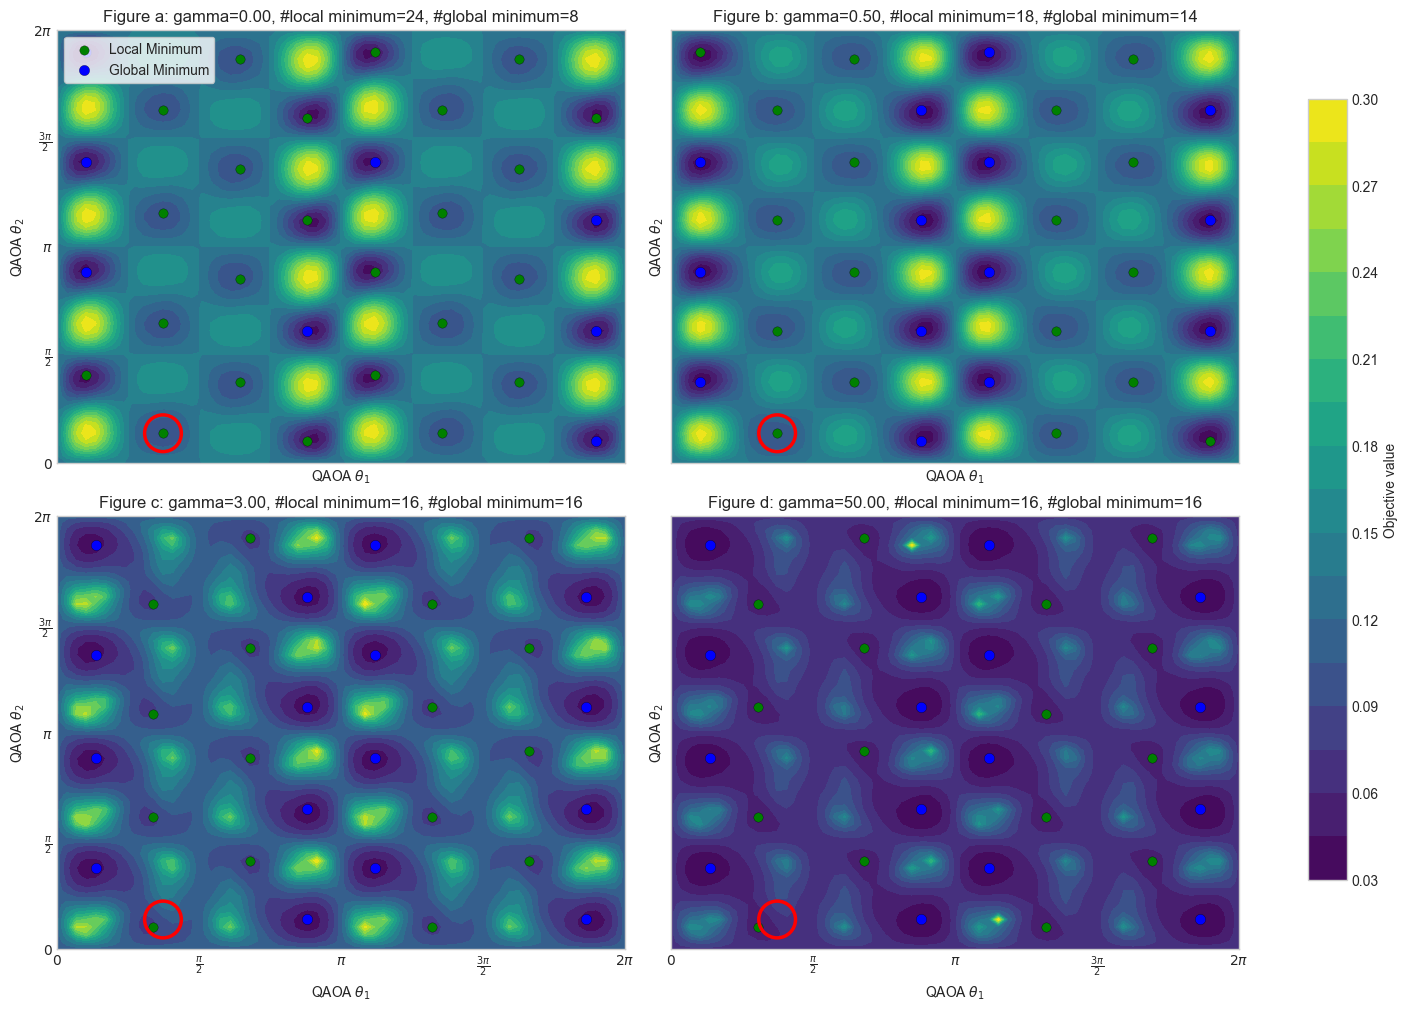

Figure 9 panel selection


,gamma,local_minima,global_minima
0,0.0,24,8
1,0.5,18,14
2,3.0,16,16
3,50.0,16,16


In [43]:
selected_panels = []
for gamma_obj in fixed_gammas:
    spec = ObjectiveSpec(f"QTL gamma={gamma_obj}", "qtl", gamma=gamma_obj, color="#2ca02c")
    obj, _, _ = make_exact_objective(n, demo_edges, spec, total_steps=24)
    surface = build_landscape(obj, theta1_axis, theta2_axis, step=0)
    local_points, global_points, smoothed = find_grid_minima(surface)
    selected_panels.append(
        {
            "gamma": gamma_obj,
            "surface": surface,
            "smoothed": smoothed,
            "locals": local_points,
            "globals": global_points,
            "local_count": len(local_points),
            "global_count": len(global_points),
        }
    )


circled_point = None
for point in selected_panels[0]["locals"]:
    if minimum_distance(point, selected_panels[1]["locals"]) > 4.0:
        continue
    if minimum_distance(point, selected_panels[2]["locals"]) <= 4.0:
        continue
    if minimum_distance(point, selected_panels[3]["locals"]) <= 4.0:
        continue
    circled_point = point
    break

if circled_point is None and selected_panels[0]["locals"]:
    circled_point = min(
        selected_panels[0]["locals"],
        key=lambda point: abs(theta1_axis[point[0]] - demo_init[0]) + abs(theta2_axis[point[1]] - demo_init[1]),
    )

candidate_coord = None
if circled_point is not None:
    candidate_coord = (theta1_axis[circled_point[0]], theta2_axis[circled_point[1]])


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True, constrained_layout=True)
for panel_id, (ax, panel) in enumerate(zip(axes.ravel(), selected_panels), start=1):
    im = ax.contourf(theta1_axis, theta2_axis, panel["surface"], levels=20, cmap="viridis")
    if panel["locals"]:
        ax.scatter(
            [theta1_axis[p[0]] for p in panel["locals"]],
            [theta2_axis[p[1]] for p in panel["locals"]],
            s=45,
            c="green",
            label="Local Minimum",
            edgecolors="black",
            linewidths=0.2,
            zorder=4,
        )
    if panel["globals"]:
        ax.scatter(
            [theta1_axis[p[0]] for p in panel["globals"]],
            [theta2_axis[p[1]] for p in panel["globals"]],
            s=55,
            c="blue",
            label="Global Minimum",
            edgecolors="black",
            linewidths=0.2,
            zorder=5,
        )
    if candidate_coord is not None:
        ax.scatter(
            [candidate_coord[0]],
            [candidate_coord[1]],
            s=700,
            facecolors="none",
            edgecolors="red",
            linewidths=2.5,
            zorder=6,
        )
    ax.set_title(
        f"Figure {chr(96 + panel_id)}: gamma={panel['gamma']:.2f}, "
        f"#local minimum={panel['local_count']}, #global minimum={panel['global_count']}"
    )
    ax.set_xlabel(r"QAOA $\theta_1$")
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2 * np.pi], [r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    ax.set_ylabel(r"QAOA $\theta_2$")
    ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2 * np.pi], [r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles, labels, frameon=True, loc="upper left")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="Objective value")

# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/qaoa for maxcut/figure_9_local_global_minima_comparison.pdf"
# fig.savefig(output_pdf, bbox_inches="tight")
plt.show()
# print(f"Saved {output_pdf}")

figure9_summary = pd.DataFrame(
    {
        "gamma": [panel["gamma"] for panel in selected_panels],
        "local_minima": [panel["local_count"] for panel in selected_panels],
        "global_minima": [panel["global_count"] for panel in selected_panels],
    }
)
figure9_summary.to_csv('optimization_landscape_data.csv')
print("Figure 9 panel selection")
display(figure9_summary)
